In [18]:
pip install pandas sqlalchemy psycopg2-binary

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


### Veriyi Databaseden çekmek

In [19]:
import pandas as pd
from sqlalchemy import create_engine

# 1. Bağlantı Bilgileri (Kendi bilgilerine göre doldur kanka)
kullanici = 'postgres'
sifre = '123456'        # Hatırlarsan bunu sıfırlamıştık, o yeni şifreyi yaz
host = 'localhost'            # Kendi bilgisayarımızda çalıştığı için localhost
port = '5432'                 # PostgreSQL'in varsayılan portu
veritabani = 'credit_risk_db' # DBeaver'da oluşturduğun veritabanının tam adı

# 2. Köprüyü İnşa Et (SQLAlchemy Engine)
# Bu satır, Python'un veritabanıyla konuşmasını sağlayan motoru kurar
engine = create_engine(f'postgresql://{kullanici}:{sifre}@{host}:{port}/{veritabani}')

# 3. Yazdığımız Efsane SQL Sorgusu
sorgu = """
SELECT 
    sk_id_curr,
    sk_id_prev,
    num_instalment_number AS taksit_sirasi,
    amt_instalment AS beklenen_tutar,
    amt_payment AS odenen_tutar,
    LAG(amt_payment, 1) OVER (PARTITION BY sk_id_curr, sk_id_prev ORDER BY num_instalment_number) AS onceki_ay_odenen,
    SUM(amt_payment) OVER (PARTITION BY sk_id_curr, sk_id_prev ORDER BY num_instalment_number) AS kumulatif_toplam
FROM 
    installments_payments
WHERE 
    sk_id_curr = 161674
ORDER BY 
    sk_id_prev, num_instalment_number
"""

# 4. Veriyi DataFrame Olarak İçeri Al
print("Veritabanına bağlanılıyor ve veri çekiliyor...")
df = pd.read_sql(sorgu, engine)
print("İşlem başarılı! DataFrame hazır.")

# İlk 5 satırı ekranda görelim
df.head()

Veritabanına bağlanılıyor ve veri çekiliyor...
İşlem başarılı! DataFrame hazır.


,sk_id_curr,sk_id_prev,taksit_sirasi,beklenen_tutar,odenen_tutar,onceki_ay_odenen,kumulatif_toplam
0,161674,1054186,1,6948.36,6948.36,NaN,6948.36
1,161674,1054186,2,6948.36,6948.36,6948.36,13896.72
2,161674,1054186,3,6948.36,6948.36,6948.36,20845.08
3,161674,1054186,4,6948.36,6948.36,6948.36,27793.44
4,161674,1054186,5,6948.36,6948.36,6948.36,34741.80


### Çektiğimiz verilerde toplanda 3 farklı tablo var bunları birleştiriyoruz

In [20]:
# Makine Öğrenmesi için Ana Veri Setini (Master Table) Çekiyoruz

master_sorgu = """
WITH BureauSummary AS (
    -- 1. Müşterilerin diğer bankalardaki toplam kredi sayısını ve borcunu özetle
    SELECT 
        sk_id_curr, 
        COUNT(sk_id_bureau) AS baska_banka_kredi_sayisi, 
        COALESCE(SUM(amt_credit_sum), 0) AS baska_banka_toplam_borc
    FROM bureau 
    GROUP BY sk_id_curr
),
InstallmentSummary AS (
    -- 2. Müşterilerin geçmiş taksitlerinde beklenen ve gerçekte ödedikleri toplam tutarı özetle
    SELECT 
        sk_id_curr, 
        SUM(amt_instalment) AS beklenen_toplam_odeme,
        SUM(amt_payment) AS gerceklesen_toplam_odeme
    FROM installments_payments 
    GROUP BY sk_id_curr
)
-- 3. Ana tablo ile bu özetleri birleştir (Tüm özellikleri tek tabloda topla)
SELECT 
    a.sk_id_curr, 
    a.target, 
    a.code_gender AS cinsiyet, 
    (a.days_birth / -365) AS yas, 
    a.amt_income_total AS yillik_gelir, 
    a.amt_credit AS istenen_kredi,
    
    COALESCE(b.baska_banka_kredi_sayisi, 0) AS baska_banka_kredi_sayisi, 
    COALESCE(b.baska_banka_toplam_borc, 0) AS baska_banka_toplam_borc,
    
    COALESCE(i.beklenen_toplam_odeme, 0) AS beklenen_toplam_odeme, 
    COALESCE(i.gerceklesen_toplam_odeme, 0) AS gerceklesen_toplam_odeme
    
FROM application_train a
LEFT JOIN BureauSummary b ON a.sk_id_curr = b.sk_id_curr
LEFT JOIN InstallmentSummary i ON a.sk_id_curr = i.sk_id_curr
"""

print("Makine Öğrenmesi veri seti veritabanından çekiliyor... (Biraz sürebilir)")
df_train = pd.read_sql(master_sorgu, engine)
print(f"İşlem tamam! Veri setinin boyutu: {df_train.shape}")

# Model verimizin ilk 5 satırına bakalım
df_train.head()

Makine Öğrenmesi veri seti veritabanından çekiliyor... (Biraz sürebilir)
İşlem tamam! Veri setinin boyutu: (307511, 10)


,sk_id_curr,target,cinsiyet,yas,yillik_gelir,istenen_kredi,baska_banka_kredi_sayisi,baska_banka_toplam_borc,beklenen_toplam_odeme,gerceklesen_toplam_odeme
0,100006,0,F,52,135000.0,312682.5,0,0.0,1007153.400,1007153.40
1,100007,0,M,54,121500.0,513000.0,1,146250.0,835985.250,806127.90
2,100014,0,F,27,112500.0,652500.0,8,2729932.5,224697.900,166880.75
3,100021,0,F,26,81000.0,270000.0,0,0.0,208357.530,208357.53
4,100033,0,M,27,270000.0,790830.0,1,675000.0,108212.086,69411.65


### Eksik veri doldurma ve One-Hot Encoding işlemi & Train | Test Split

#### Sayısal kolonlardaki boşlukları o kolonun ortanca değeriyle (medyan), metin kolonlarındakileri ise en çok tekrar eden değerle (mod) dolduracağız.

#### Kategorik verileri algoritmaya anlatmanın en popüler yolu One-Hot Encoding yöntemidir.Pandas'taki pd.get_dummies() fonksiyonunu kullanarak "cinsiyet" kolonunu parçalayacağız. Eğer müşteri erkekse "Cinsiyet_M" kolonuna 1, değilse 0 yazacak.

In [21]:
# 1. ADIM: Eksik Veri (NaN) Temizliği
print("Eksik veriler dolduruluyor...")

# Sayısal kolonlardaki boşlukları medyan (ortanca) ile doldur
df_train.fillna(df_train.median(numeric_only=True), inplace=True)

# Kategorik (metin) kolonlardaki boşlukları en sık geçen değer (mode) ile doldur
for col in df_train.select_dtypes(include=['object']).columns:
    df_train[col].fillna(df_train[col].mode()[0], inplace=True)

# 2. ADIM: Kategorik Verileri Sayısallaştırma (One-Hot Encoding)
print("Metin verileri sayısallaştırılıyor...")
# drop_first=True parametresi, Dummy Variable Trap (Kukla Değişken Tuzağı) denen matematiksel sorunu engeller
df_train = pd.get_dummies(df_train, columns=['cinsiyet'], drop_first=True)

# 3. ADIM: Hedef (y) ve Özelliklerin (X) Ayrılması
print("X ve y ayrıştırılıyor...")
y = df_train['target']

# ID kolonu tahmin için işe yaramaz, Target ise zaten aradığımız şey. İkisini de atıyoruz.
X = df_train.drop(['target', 'sk_id_curr'], axis=1) 

print("-" * 30)
print("X (Özellikler) boyutu:", X.shape)
print("y (Hedef) boyutu:", y.shape)

# Son halini görelim
X.head()

Eksik veriler dolduruluyor...
Metin verileri sayısallaştırılıyor...
X ve y ayrıştırılıyor...
------------------------------
X (Özellikler) boyutu: (307511, 9)
y (Hedef) boyutu: (307511,)


C:\Users\Muhammed Fakılı\AppData\Local\Temp\ipykernel_3424\4161185912.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_train[col].fillna(df_train[col].mode()[0], inplace=True)


,yas,yillik_gelir,istenen_kredi,baska_banka_kredi_sayisi,baska_banka_toplam_borc,beklenen_toplam_odeme,gerceklesen_toplam_odeme,cinsiyet_M,cinsiyet_XNA
0,52,135000.0,312682.5,0,0.0,1007153.400,1007153.40,False,False
1,54,121500.0,513000.0,1,146250.0,835985.250,806127.90,True,False
2,27,112500.0,652500.0,8,2729932.5,224697.900,166880.75,False,False
3,26,81000.0,270000.0,0,0.0,208357.530,208357.53,False,False
4,27,270000.0,790830.0,1,675000.0,108212.086,69411.65,True,False


### Model eğitimi ve validasyon

In [22]:
# Eğer kütüphaneler yüklü değilse baştaki '#' işaretini kaldırıp çalıştırabilirsin
# !pip install xgboost scikit-learn

from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. ADIM: Veriyi Eğitim (%80) ve Test (%20) Olarak Ayırma
# stratify=y parametresi, o %8'lik riskli grubun hem eğitime hem teste eşit dağılmasını sağlar
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Eğitim ve Test setleri ayrıldı!")

# 2. ADIM: XGBoost Modelini Kurma
# scale_pos_weight = 92 / 8 (Yaklaşık 11). Modelimize "1 riskli müşteri, 11 risksiz müşteriye bedeldir" diyoruz.
xgb_model = XGBClassifier(
    scale_pos_weight=11, 
    random_state=42,
    eval_metric='logloss'
)

# 3. ADIM: Modeli Eğitme (Makine Öğreniyor...)
print("XGBoost Modeli eğitiliyor... (Veri büyük olduğu için 1-2 dakika sürebilir, arkanı yasla ve bekle)")
xgb_model.fit(X_train, y_train)
print("Eğitim başarıyla tamamlandı!")

# 4. ADIM: Test Seti Üzerinde Tahmin ve Sonuçlar
y_pred = xgb_model.predict(X_test)

print("\n--- Sınıflandırma Raporu (Classification Report) ---")
print(classification_report(y_test, y_pred))

Eğitim ve Test setleri ayrıldı!
XGBoost Modeli eğitiliyor... (Veri büyük olduğu için 1-2 dakika sürebilir, arkanı yasla ve bekle)
Eğitim başarıyla tamamlandı!

--- Sınıflandırma Raporu (Classification Report) ---
              precision    recall  f1-score   support

           0       0.94      0.69      0.79     56538
           1       0.12      0.50      0.20      4965

    accuracy                           0.67     61503
   macro avg       0.53      0.59      0.50     61503
weighted avg       0.87      0.67      0.75     61503



### Model Tunning

In [23]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import time

print("Hiperparametre optimizasyonu başlıyor...")
baslangic = time.time()

# 1. Stratejik ve Daraltılmış Parametre Izgarası
param_grid = {
    'max_depth': [3, 5],             # Karar ağaçlarının derinliği
    'learning_rate': [0.05, 0.1],    # Öğrenme hızı
    'n_estimators': [100, 200]       # Toplam ağaç sayısı
}
# Toplam kombinasyon: 2 x 2 x 2 = 8 farklı model. 
# cv=3 ile çarpılınca toplam 24 kere eğitim yapılacak!

# 2. Temel Modelin (Base Model) Kurulması
# Dengesiz veri setimiz için scale_pos_weight parametremizi korumak zorundayız
xgb_base = XGBClassifier(
    scale_pos_weight=11, 
    random_state=42, 
    eval_metric='logloss'
)

# 3. Çapraz Doğrulama (Cross-Validation) Yapısı
# Riskli müşterilerin her eğitim parçasında eşit dağılmasını garanti altına alır
cv_yapisi = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# 4. GridSearchCV Kurulumu
# Amacımız F1-Score'u maksimize etmek olduğu için scoring='f1' seçiyoruz
grid_search = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    scoring='f1',
    cv=cv_yapisi,
    verbose=2, # Ekrana adım adım eğitim sürecini yazdırır
    n_jobs=-1  # Bilgisayarın tüm işlemci çekirdeklerini kullan (Çok önemli!)
)

# 5. Arama Başlasın!
grid_search.fit(X_train, y_train)

bitis = time.time()
print(f"\nOptimizasyon tamamlandı! Toplam Süre: {round((bitis - baslangic)/60, 2)} dakika.")

# 6. En İyi Parametreler ve Yeni Tahminler
print("\nBulunan En İyi Parametreler:", grid_search.best_params_)

# Model artık en iyi parametrelerle otomatik olarak güncellendi. Yeni tahminleri alıyoruz:
en_iyi_model = grid_search.best_estimator_
y_pred_tuned = en_iyi_model.predict(X_test)

print("\n--- YENİ Sınıflandırma Raporu (Tuned Model) ---")
print(classification_report(y_test, y_pred_tuned))

Hiperparametre optimizasyonu başlıyor...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Optimizasyon tamamlandı! Toplam Süre: 0.19 dakika.

Bulunan En İyi Parametreler: {'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 200}

--- YENİ Sınıflandırma Raporu (Tuned Model) ---
              precision    recall  f1-score   support

           0       0.94      0.66      0.78     56538
           1       0.12      0.54      0.20      4965

    accuracy                           0.65     61503
   macro avg       0.53      0.60      0.49     61503
weighted avg       0.88      0.65      0.73     61503



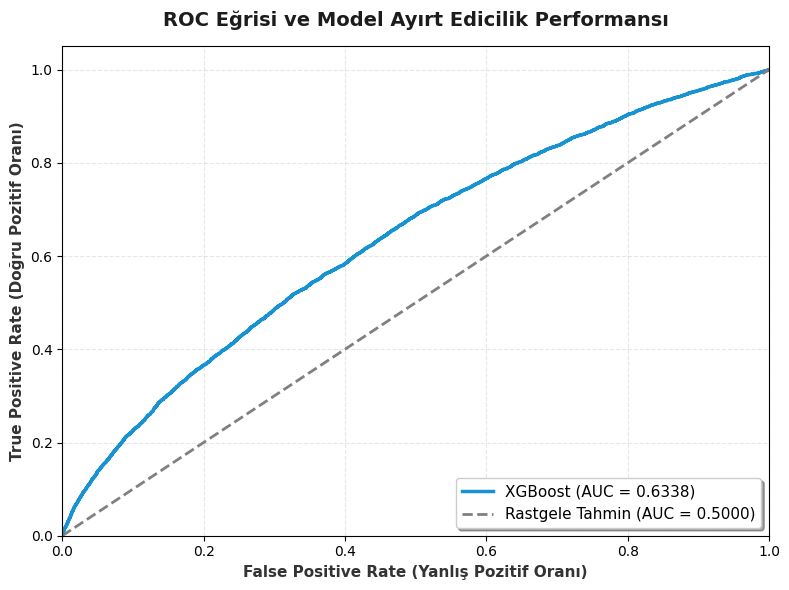

In [24]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. ADIM: Eksik olan değişkeni oluşturuyoruz (Modelin tahmin olasılıkları hesaplanıyor)
# Not: Eğer veriyi ayırırken adını X_val yaptıysan, X_test yazan yeri X_val yap.
xgb_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

# 2. ADIM: ROC eğrisi için False Positive ve True Positive hesaplamaları
fpr, tpr, thresholds = roc_curve(y_test, xgb_pred_proba)
roc_auc = auc(fpr, tpr)

# 3. ADIM: Grafiğin boyut ve stil ayarları
plt.figure(figsize=(8, 6))

# XGBoost Modelinin ROC Eğrisi 
plt.plot(fpr, tpr, color='#1793D1', lw=2.5, label=f'XGBoost (AUC = {roc_auc:.4f})')

# Rastgele tahmin (Baseline) çizgisi
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Rastgele Tahmin (AUC = 0.5000)')

# Eksen ve Başlık Tasarımları
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Yanlış Pozitif Oranı)', fontsize=11, fontweight='bold', color='#333333')
plt.ylabel('True Positive Rate (Doğru Pozitif Oranı)', fontsize=11, fontweight='bold', color='#333333')
plt.title('ROC Eğrisi ve Model Ayırt Edicilik Performansı', fontsize=14, fontweight='bold', color='#1C1C1C', pad=15)

# Lejant ve Izgara Ayarları
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(alpha=0.3, linestyle='--')

# Grafiği Ekrana Basma
plt.tight_layout()
plt.show()

In [25]:
import numpy as np

print("Power BI için veriler hazırlanıyor...")

# 1. Modelin Kesin Tahminlerini (0 veya 1) ve Risk Olasılıklarını (%0-100 arası) alalım
y_pred_tuned = en_iyi_model.predict(X_test)
y_prob_tuned = en_iyi_model.predict_proba(X_test)[:, 1] # Sadece "1" (Riskli) olma olasılıkları

# 2. X_test tablosunun bir kopyasını alıp yeni kolonlarımızı ekleyelim
df_powerbi = X_test.copy()
df_powerbi['Gercek_Durum'] = y_test
df_powerbi['Model_Tahmini'] = y_pred_tuned
df_powerbi['Risk_Olasiligi'] = y_prob_tuned

# 3. Müşterileri Segmentlere Ayıralım (Bunu Power BI'da DAX ile de yapabilirdik ama Python'da yapmak raporu çok hızlandırır)
df_powerbi['Risk_Segmenti'] = pd.cut(
    df_powerbi['Risk_Olasiligi'], 
    bins=[-np.inf, 0.30, 0.65, np.inf], 
    labels=['Düşük Risk', 'Orta Risk', 'Yüksek Risk']
)

# 4. Veriyi CSV olarak kaydedelim
dosya_adi = "powerbi_kredi_risk_verisi.csv"
df_powerbi.to_csv(dosya_adi, index=False)

print(f"İşlem Tamam! Veriler '{dosya_adi}' adıyla kaydedildi. Artık Power BI'a geçebiliriz.")

Power BI için veriler hazırlanıyor...
İşlem Tamam! Veriler 'powerbi_kredi_risk_verisi.csv' adıyla kaydedildi. Artık Power BI'a geçebiliriz.


In [26]:
from xgboost import XGBClassifier
from sklearn.metrics import roc_curve, auc

print("Model optimize ediliyor, lütfen bekleyin...")

# XGBoost'un finansal veriler için optimize edilmiş parametreleri
xgb_model_tuned = XGBClassifier(
    n_estimators=300,        # Ağaç sayısını artırdık (Daha çok öğrenme şansı)
    max_depth=4,             # Ezberlemeyi (overfit) önlemek için derinliği 4'e çektik
    learning_rate=0.05,      # Daha yavaş ama daha sağlam adımlarla öğrenme
    subsample=0.8,           # Her ağaçta verinin rastgele %80'ini kullanarak ezberi boz
    colsample_bytree=0.8,    # Her ağaçta kolonların %80'ini al (Gürültülü kolonların etkisini azaltır)
    scale_pos_weight=11,     # Batık sınıfına verdiğimiz ceza ağırlığı (Dengesiz veri için)
    random_state=42,
    n_jobs=-1,
    eval_metric="auc"
)

# Optimize edilmiş modeli eğitiyoruz (Eğer eğitim verinin adı X_train değilse burayı düzelt kanka)
xgb_model_tuned.fit(X_train, y_train)

# Yeni tahmin olasılıkları (Yine X_test yerine X_val kullanıyorsan değiştir)
xgb_pred_proba_tuned = xgb_model_tuned.predict_proba(X_test)[:, 1]

# Yeni ROC-AUC Skoru
fpr_tuned, tpr_tuned, thresholds_tuned = roc_curve(y_test, xgb_pred_proba_tuned)
yeni_roc_auc = auc(fpr_tuned, tpr_tuned)

print(f"🚀 Yeni ve Optimize Edilmiş ROC-AUC Skorumuz: {yeni_roc_auc:.4f}")

Model optimize ediliyor, lütfen bekleyin...
🚀 Yeni ve Optimize Edilmiş ROC-AUC Skorumuz: 0.6422


In [ ]:
import numpy as np
import pandas as pd

print("Power BI için veriler hazırlanıyor...")

# 1. Eğittiğin optimize model (xgb_model_tuned) üzerinden kesin tahminleri (0 veya 1) alalım
y_pred_tuned = xgb_model_tuned.predict(X_test)

# 2. Orijinal X_test tablosunun bir kopyasını alıp model çıktılarını ekleyelim
# Kolon silmediğimiz için doğrudan X_test'i güvenle kopyalıyoruz
df_powerbi = X_test.copy()
df_powerbi['Gercek_Durum'] = y_test
df_powerbi['Model_Tahmini'] = y_pred_tuned

# Bir önceki hücrede hesaplattığın olasılık dizisini doğrudan buraya bağlıyoruz
df_powerbi['Risk_Olasiligi'] = xgb_pred_proba_tuned 

# 3. Müşterileri Risk Skoruna göre segmentlere ayıralım
df_powerbi['Risk_Segmenti'] = pd.cut(
    df_powerbi['Risk_Olasiligi'], 
    bins=[-np.inf, 0.30, 0.65, np.inf], 
    labels=['Düşük Risk', 'Orta Risk', 'Yüksek Risk']
)

# 4. Veriyi CSV olarak dışarı aktaralım
dosya_adi = "powerbi_kredi_risk_verisi.csv"
df_powerbi.to_csv(dosya_adi, index=False)

print(f"🚀 İşlem Tamam! Tüm kolonların korunduğu güncel veri seti '{dosya_adi}' adıyla kaydedildi.")

Power BI için veriler hazırlanıyor...
🚀 İşlem Tamam! Tüm kolonların korunduğu güncel veri seti 'powerbi_kredi_risk_verisi.csv' adıyla kaydedildi. Power BI'da Refresh yapmaya hazırsın kanka!
